<a href="https://colab.research.google.com/github/anteodor/Introduction-to-Machine-Learning/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 — Stroke Prediction using K-Nearest Neighbors

**Student:** Anastasiia Teodorovska  
**Course:** Machine Learning in Data  
**Task:** Build, evaluate, and fine-tune a K-Nearest Neighbors model for stroke prediction using the Kaggle Stroke Prediction Dataset.

## Importing the required libraries

At this stage, the essential Python libraries required for data loading, preprocessing, model development, and evaluation were imported.

The **pandas** library is utilized for data manipulation and analysis, providing flexible data structures for handling tabular datasets. The **numpy** library supports numerical computations and efficient operations on arrays, which are fundamental in machine learning workflows.

To enable file uploading in the Google Colab environment, the **files** module from **google.colab** is used. This allows seamless integration of external datasets into the notebook environment.

For building the machine learning model, components from the **scikit-learn** library were employed. The **KNeighborsClassifier** was selected as the primary algorithm due to its simplicity and effectiveness in classification tasks, particularly for problems involving similarity-based learning.

Data preprocessing is performed using **Pipeline**, **ColumnTransformer**, **StandardScaler**, **OneHotEncoder**, and **SimpleImputer**. These tools ensure that numerical features are properly scaled, categorical variables are encoded, and missing values are handled appropriately. The use of pipelines guarantees a clean, reproducible, and structured preprocessing workflow.

To properly evaluate the model, functions such as **train_test_split** are used to divide the dataset into training and testing subsets. Additionally, performance metrics including **accuracy**, **precision**, **recall**, and **F1-score** are applied to provide a comprehensive assessment of the model’s effectiveness.

For model optimization, **GridSearchCV** is used to perform systematic hyperparameter tuning, allowing the identification of the optimal number of neighbors and distance metrics for the KNN model.

Finally, visualization tools such as **matplotlib** are utilized to present results, particularly for displaying the confusion matrix, which provides insight into the classification performance of the model.

In [1]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Loading the dataset

At this stage, the dataset used for stroke prediction was loaded into the working environment.

Since the implementation is performed in **Google Colab**, the dataset is uploaded manually using the `files.upload()` function. This approach allows flexible integration of external `.csv` files directly from the local machine into the notebook.

After uploading, the file name is dynamically retrieved, ensuring that the code remains **universal** and does not depend on hardcoded paths. The dataset is then loaded into a **pandas DataFrame** using the `read_csv()` function, which is a standard and efficient method for handling structured tabular data.

Displaying the first few rows of the dataset using `df.head()` provides an initial understanding of the data structure, feature names, and value distributions. This step is crucial for verifying that the dataset has been loaded correctly and for gaining preliminary insights before proceeding to deeper data analysis and preprocessing.

This stage forms the foundation for all subsequent steps, as correct data loading ensures the integrity and reliability of the entire machine learning pipeline.

In [2]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Initial data analysis using structured summary tables

At this stage, an exploratory analysis of the dataset was performed using structured **pandas DataFrames**, which provide a clear and professional representation of key dataset characteristics.

First, a summary table describing the overall structure of the dataset was created. This includes the total number of observations and features, allowing for a quick assessment of the dataset size and complexity.

Next, a detailed **feature-level summary table** was constructed. For each feature, the following attributes were analyzed:
- data type, which determines the appropriate preprocessing techniques,
- number of non-null values, indicating data completeness,
- number of missing values, highlighting potential data quality issues,
- percentage of missing values, providing a normalized and more interpretable measure of missingness.

The inclusion of the **percentage of missing values** is particularly important, as it enables easier comparison across features and helps prioritize preprocessing efforts. Additionally, the table is sorted in descending order based on missing percentage, ensuring that the most problematic features are immediately visible.

Furthermore, the distribution of the target variable (`stroke`) was analyzed and presented as a separate table, including both absolute counts and percentage values. This allows for clear identification of potential class imbalance, which is a critical factor in medical prediction tasks and directly impacts model evaluation and performance.

Overall, the use of structured summary tables significantly improves readability, interpretability, and professionalism of the analysis. It also aligns with best practices in data science, where clear and concise data exploration is essential for building reliable machine learning models.

In [5]:
# Basic dataset info
shape_df = pd.DataFrame({
    "Metric": ["Number of rows", "Number of columns"],
    "Value": [df.shape[0], df.shape[1]]
})

# Feature info with % missing
info_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Missing Values": df.isnull().sum().values
})

# Percentage of missing values
info_df["Missing (%)"] = (
    info_df["Missing Values"] / len(df) * 100
).round(2)

# Sort by missing values (descending)
info_df = info_df.sort_values(by="Missing (%)", ascending=False)

# Target distribution
target_df = df["stroke"].value_counts().reset_index()
target_df.columns = ["Class", "Count"]

# Add percentage for target distribution
target_df["Percentage (%)"] = (
    target_df["Count"] / target_df["Count"].sum() * 100
).round(2)

# Display all tables
print("=== DATASET OVERVIEW ===")
display(shape_df)

print("\n=== FEATURE SUMMARY ===")
display(info_df)

print("\n=== TARGET DISTRIBUTION ===")
display(target_df)

=== DATASET OVERVIEW ===


,Metric,Value
0,Number of rows,5110
1,Number of columns,12



=== FEATURE SUMMARY ===


,Feature,Data Type,Non-Null Count,Missing Values,Missing (%)
9,bmi,float64,4909,201,3.93
0,id,int64,5110,0,0.00
2,age,float64,5110,0,0.00
1,gender,object,5110,0,0.00
3,hypertension,int64,5110,0,0.00
4,heart_disease,int64,5110,0,0.00
6,work_type,object,5110,0,0.00
5,ever_married,object,5110,0,0.00
7,Residence_type,object,5110,0,0.00
8,avg_glucose_level,float64,5110,0,0.00



=== TARGET DISTRIBUTION ===


,Class,Count,Percentage (%)
0,0,4861,95.13
1,1,249,4.87


## Data preparation and feature selection

At this stage, the dataset was prepared for machine learning modeling by separating features and defining the target variable, as well as identifying the types of input variables.

First, the `id` column was removed from the dataset. This feature serves only as a unique identifier for each record and does not contain any meaningful information for prediction. Including such attributes in the model could negatively impact performance and introduce unnecessary noise.

Next, the dataset was divided into:
- **input features (X)** — all variables used to predict the outcome,
- **target variable (y)** — the `stroke` column, which represents whether a patient experienced a stroke.

This separation is a fundamental step in supervised learning, as it clearly defines the inputs and the expected output of the model.

Afterward, features were categorized into two groups based on their data types:
- **categorical features**, which contain non-numeric values (e.g., gender, work type, smoking status),
- **numerical features**, which include integer and floating-point values (e.g., age, glucose level, BMI).

This distinction is critically important because different preprocessing techniques must be applied to each type:
- categorical variables require encoding (e.g., one-hot encoding),
- numerical variables require scaling to ensure consistent magnitude across features.

Identifying feature types at this stage enables the construction of a structured and efficient preprocessing pipeline in the subsequent steps.

In [6]:
# The 'id' column is not useful for prediction
df = df.drop(columns=["id"])

X = df.drop(columns=["stroke"])
y = df["stroke"]

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:", list(categorical_features))
print("Numerical features:", list(numerical_features))

Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Numerical features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


## Data preprocessing pipeline

At this stage, a structured and reusable **data preprocessing pipeline** was constructed to ensure that all input features are properly prepared for the K-Nearest Neighbors (KNN) model.

Since the dataset contains both numerical and categorical variables, different preprocessing strategies were applied to each type of data.

For **numerical features**, the following steps were performed:
- Missing values were handled using the **median imputation strategy**. The median is a robust measure that is less sensitive to outliers compared to the mean, making it particularly suitable for medical data.
- Feature scaling was applied using **StandardScaler**, which standardizes features by removing the mean and scaling to unit variance. This step is essential for KNN, as the algorithm relies on distance calculations, and unscaled features can disproportionately influence the results.

For **categorical features**, a separate preprocessing pipeline was defined:
- Missing values were replaced using the **most frequent value (mode)**, which preserves the distribution of categorical data.
- Categorical variables were transformed using **One-Hot Encoding**, converting each category into a binary vector. This allows the model to process non-numeric data effectively. The `handle_unknown="ignore"` parameter ensures that the pipeline remains robust when encountering unseen categories during inference.

Both preprocessing pipelines were then combined using a **ColumnTransformer**, which applies the appropriate transformations to the corresponding feature groups in a single unified workflow.

This pipeline-based approach ensures:
- consistency between training and testing data,
- reproducibility of preprocessing steps,
- clean integration with machine learning models.

Overall, this design follows best practices in machine learning by encapsulating all preprocessing logic into a single, maintainable, and scalable structure.

In [8]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Splitting the dataset into training and testing sets

At this stage, the dataset was divided into **training** and **testing** subsets in order to properly evaluate the performance of the machine learning model.

The split was performed using the `train_test_split` function from the **scikit-learn** library. Specifically, **80% of the data** was allocated for training the model, while the remaining **20% was reserved for testing**. This ratio is commonly used in practice, as it provides a sufficient amount of data for both learning and unbiased evaluation.

The `random_state=42` parameter was set to ensure **reproducibility** of the results. By fixing the random seed, the same data split can be obtained across different runs, which is essential for consistent experimentation and comparison.

Additionally, the `stratify=y` parameter was applied. This is a crucial step, especially for medical datasets, as it ensures that the **distribution of the target variable (stroke vs. non-stroke cases)** is preserved in both the training and testing sets. Without stratification, the model could be trained or evaluated on unrepresentative samples, leading to misleading performance metrics.

Finally, the shapes of the resulting subsets were displayed to verify that the split was performed correctly.

This step is fundamental in machine learning, as it enables an objective assessment of how well the model generalizes to unseen data.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4088, 10)
Testing set: (1022, 10)


## Building and training the K-Nearest Neighbors model

At this stage, the **K-Nearest Neighbors (KNN)** classification model was constructed and trained using the prepared dataset.

A **Pipeline** was used to combine both the preprocessing steps and the machine learning algorithm into a single unified workflow. This approach ensures that all transformations (such as imputation, encoding, and scaling) are consistently applied to both training and testing data, eliminating the risk of data leakage and improving reproducibility.

The **KNeighborsClassifier** was selected as the core model due to its intuitive nature and effectiveness in classification problems based on similarity between data points. The algorithm works by identifying the *k* closest neighbors to a given instance and assigning the most frequent class among them.

In this implementation, the number of neighbors was initially set to **k = 5**, which is a commonly used default value that provides a balance between model complexity and generalization. This value serves as a baseline and can be further optimized in later stages.

The model was then trained using the `fit()` method on the training dataset. During this process, the pipeline automatically applied all preprocessing transformations before fitting the KNN classifier.

Finally, predictions were generated on the testing dataset using the `predict()` method. These predictions will be used in the next stage to evaluate the performance of the model.

This pipeline-based approach ensures a clean, efficient, and production-ready implementation of the machine learning workflow.


In [10]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

## Model evaluation using structured performance tables

At this stage, the performance of the baseline **K-Nearest Neighbors (KNN)** model was evaluated using a set of standard classification metrics, presented in the form of structured **pandas DataFrames**.

First, the key evaluation metrics were calculated:
- **Accuracy**, which measures the overall proportion of correctly classified instances,
- **Precision**, which indicates how many of the predicted positive cases are actually correct,
- **Recall**, which reflects the model’s ability to correctly identify positive cases (stroke events),
- **F1-score**, which provides a balanced measure by combining precision and recall.

These metrics were organized into a dedicated summary table, ensuring a clear and concise overview of the model’s performance. The values were rounded to four decimal places to improve readability and maintain a professional presentation standard.

In addition, a detailed **classification report** was generated and converted into a pandas DataFrame. This report includes class-wise metrics such as precision, recall, F1-score, and support, offering deeper insight into how the model performs for each class (stroke vs. non-stroke cases).

Presenting the evaluation results in tabular form significantly enhances clarity and aligns with best practices in data science reporting. It allows for easier interpretation, comparison, and integration into formal documentation.

Overall, this stage provides a comprehensive and structured assessment of the baseline model, forming the basis for further improvements and optimization.

In [11]:
# Calculate metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

# Round values
metrics_df["Value"] = metrics_df["Value"].round(4)

# Classification report as DataFrame
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

# Round for better readability
report_df = report_df.round(4)

# Display results
print("=== MODEL PERFORMANCE METRICS ===")
display(metrics_df)

print("\n=== CLASSIFICATION REPORT ===")
display(report_df)

=== MODEL PERFORMANCE METRICS ===


,Metric,Value
0,Accuracy,0.9481
1,Precision,0.0000
2,Recall,0.0000
3,F1-score,0.0000



=== CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
0,0.9509,0.9969,0.9734,972.0000
1,0.0000,0.0000,0.0000,50.0000
accuracy,0.9481,0.9481,0.9481,0.9481
macro avg,0.4755,0.4985,0.4867,1022.0000
weighted avg,0.9044,0.9481,0.9258,1022.0000


## Confusion matrix analysis

At this stage, a **confusion matrix** was constructed to provide a detailed evaluation of the classification performance of the baseline K-Nearest Neighbors (KNN) model.

Unlike aggregate metrics such as accuracy or F1-score, the confusion matrix offers a **granular view of prediction outcomes**, allowing for a deeper understanding of how the model performs on each class.

The confusion matrix consists of four key components:
- **True Positives (TP)** — correctly predicted stroke cases,
- **True Negatives (TN)** — correctly predicted non-stroke cases,
- **False Positives (FP)** — non-stroke cases incorrectly predicted as stroke,
- **False Negatives (FN)** — stroke cases incorrectly predicted as non-stroke.

In the context of medical prediction, particular attention should be paid to **false negatives**, as failing to identify a stroke case may have serious real-world consequences. Therefore, this visualization is critical for assessing the model beyond standard metrics.

The confusion matrix is visualized using **ConfusionMatrixDisplay**, providing a clear and interpretable graphical representation of classification results. The use of labeled classes ("No Stroke" and "Stroke") enhances readability and ensures that the results are easily understandable.

Overall, this step complements the numerical evaluation metrics by offering an intuitive and detailed perspective on model performance, which is especially important in healthcare-related applications.

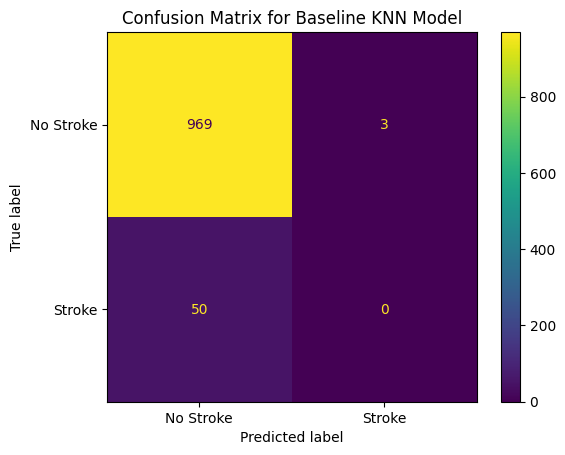

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Stroke", "Stroke"]
)

disp.plot(cmap="viridis", values_format="d")
plt.title("Confusion Matrix for Baseline KNN Model")
plt.show()

## Hyperparameter tuning using Grid Search

At this stage, the performance of the K-Nearest Neighbors (KNN) model was further improved through **hyperparameter tuning** using the **GridSearchCV** technique.

The initial model was built using a default number of neighbors (k = 5), which serves as a baseline. However, the performance of KNN is highly sensitive to its hyperparameters, particularly:
- the number of neighbors (**n_neighbors**),
- the weighting strategy (**weights**),
- the distance metric (**metric**).

To identify the optimal combination of these parameters, a **parameter grid** was defined. This grid systematically explores multiple configurations:
- values of *k* from 1 to 30,
- different weighting strategies (`uniform` and `distance`),
- distance metrics (`euclidean` and `manhattan`).

The **GridSearchCV** method performs an exhaustive search over all parameter combinations using **5-fold cross-validation**. This means that the training dataset is split into five subsets, and the model is trained and validated multiple times to ensure robust and reliable performance estimation.

The evaluation metric selected for optimization is the **F1-score**, which is particularly appropriate for imbalanced datasets, such as stroke prediction, where both precision and recall are important.

The `n_jobs=-1` parameter enables parallel computation, significantly improving efficiency by utilizing all available CPU cores.

As a result, the best-performing set of hyperparameters is identified, along with the corresponding cross-validation score. This optimized configuration is then used to build a more accurate and reliable final model.

Overall, this step enhances the model’s predictive performance and ensures that the chosen parameters are not arbitrary, but instead data-driven and systematically validated.

In [13]:
param_grid = {
    "classifier__n_neighbors": range(1, 31),
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}

Best cross-validation F1-score:
0.08733101382576522


## Final model evaluation using optimized KNN

At this stage, the performance of the **optimized K-Nearest Neighbors (KNN)** model was evaluated using the best hyperparameters identified through the Grid Search process.

The model obtained from `grid_search.best_estimator_` represents the most effective configuration based on cross-validation results. This optimized model was then applied to the testing dataset to generate predictions, ensuring that evaluation is performed on previously unseen data.

To maintain consistency and clarity in reporting, the evaluation results were presented using structured **pandas DataFrames**.

First, a summary table of key performance metrics was constructed, including:
- **Accuracy**, representing the overall correctness of predictions,
- **Precision**, indicating the reliability of positive predictions,
- **Recall**, reflecting the model’s ability to detect stroke cases,
- **F1-score**, providing a balanced measure of precision and recall.

All metric values were rounded to four decimal places to ensure readability and a professional presentation format.

Additionally, a detailed **classification report** was generated and converted into a tabular format. This report provides class-wise evaluation metrics along with support values, enabling a deeper understanding of how the optimized model performs across different classes.

Presenting the results in structured tables enhances interpretability and allows for easier comparison with the baseline model. This step confirms whether hyperparameter tuning has led to a meaningful improvement in model performance.

Overall, this stage provides a comprehensive and refined evaluation of the final model, demonstrating the effectiveness of the optimization process.

In [14]:
best_knn_model = grid_search.best_estimator_

y_pred_best = best_knn_model.predict(X_test)

# Metrics for optimized model
optimized_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Optimized KNN": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best, zero_division=0),
        recall_score(y_test, y_pred_best, zero_division=0),
        f1_score(y_test, y_pred_best, zero_division=0)
    ]
})

# Round values
optimized_metrics_df["Optimized KNN"] = optimized_metrics_df["Optimized KNN"].round(4)

# Classification report
optimized_report_dict = classification_report(
    y_test,
    y_pred_best,
    output_dict=True,
    zero_division=0
)

optimized_report_df = pd.DataFrame(optimized_report_dict).transpose().round(4)

# Display results
print("=== OPTIMIZED MODEL METRICS ===")
display(optimized_metrics_df)

print("\n=== OPTIMIZED MODEL CLASSIFICATION REPORT ===")
display(optimized_report_df)

=== OPTIMIZED MODEL METRICS ===


,Metric,Optimized KNN
0,Accuracy,0.9149
1,Precision,0.1064
2,Recall,0.1000
3,F1-score,0.1031



=== OPTIMIZED MODEL CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
0,0.9538,0.9568,0.9553,972.0000
1,0.1064,0.1000,0.1031,50.0000
accuracy,0.9149,0.9149,0.9149,0.9149
macro avg,0.5301,0.5284,0.5292,1022.0000
weighted avg,0.9124,0.9149,0.9136,1022.0000


## Confusion matrix analysis for the optimized model

At this stage, the performance of the **optimized K-Nearest Neighbors (KNN)** model was further analyzed using a confusion matrix.

The confusion matrix provides a detailed breakdown of the model’s predictions by comparing the actual and predicted class labels. This allows for a deeper evaluation beyond aggregate metrics such as accuracy or F1-score.

The matrix includes the following components:
- **True Positives (TP)** — correctly identified stroke cases,
- **True Negatives (TN)** — correctly identified non-stroke cases,
- **False Positives (FP)** — non-stroke cases incorrectly classified as stroke,
- **False Negatives (FN)** — stroke cases incorrectly classified as non-stroke.

In medical prediction tasks, particular emphasis is placed on minimizing **false negatives**, as failing to detect a stroke case may lead to serious consequences. Therefore, analyzing the confusion matrix is essential for understanding the practical reliability of the model.

The matrix is visualized using **ConfusionMatrixDisplay**, providing a clear graphical representation of classification outcomes. Consistent labeling of classes ("No Stroke" and "Stroke") ensures that the results are intuitive and easy to interpret.

Comparing this confusion matrix with that of the baseline model allows for assessment of how hyperparameter tuning has influenced prediction quality, particularly in terms of reducing misclassifications.

Overall, this step provides valuable insight into the strengths and limitations of the optimized model, supporting a more informed evaluation of its performance in a real-world context.

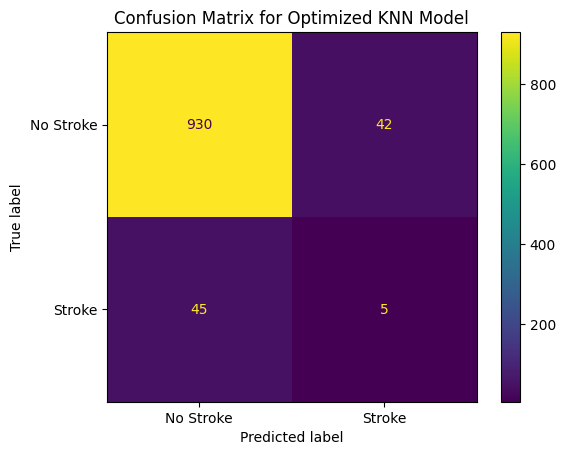

In [24]:
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["No Stroke", "Stroke"]
)

disp.plot(cmap="viridis", values_format="d")
plt.title("Confusion Matrix for Optimized KNN Model")
plt.show()

## Comparative analysis of baseline and optimized models

At this stage, a comparative analysis between the **baseline K-Nearest Neighbors (KNN)** model and the **optimized KNN model** was conducted in order to evaluate the impact of hyperparameter tuning.

Instead of presenting results separately, the evaluation metrics from both models were consolidated into a single structured **pandas DataFrame**. This approach enables direct comparison across key performance indicators, including:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

The metrics for the baseline model were extracted from the previously created evaluation table, while the metrics for the optimized model were obtained from the corresponding optimized results. These were then combined into a unified table using column-wise concatenation.

This tabular comparison provides a clear and concise overview of how model performance has changed after optimization. It allows for immediate identification of improvements or trade-offs across different metrics.

Such comparative analysis is a crucial step in machine learning workflows, as it validates whether the applied optimization techniques have led to meaningful performance gains. It also supports data-driven decision-making when selecting the final model for deployment or further analysis.

Overall, this stage enhances the interpretability of results and demonstrates a systematic and professional approach to model evaluation.

In [17]:
# Extract baseline metrics
baseline_metrics = metrics_df.set_index("Metric")["Value"]

# Extract optimized metrics
optimized_metrics = optimized_metrics_df.set_index("Metric")["Optimized KNN"]

# Combine into one table
comparison_df = pd.concat(
    [baseline_metrics, optimized_metrics],
    axis=1
)

comparison_df.columns = ["Baseline KNN", "Optimized KNN"]

# Round values
comparison_df = comparison_df.round(4)

display(comparison_df)

,Baseline KNN,Optimized KNN
Metric,,
Accuracy,0.9481,0.9149
Precision,0.0000,0.1064
Recall,0.0000,0.1000
F1-score,0.0000,0.1031


## Analysis of results

The evaluation of the K-Nearest Neighbors (KNN) model reveals several important insights regarding its performance and limitations, particularly in the context of imbalanced medical data.

First, the baseline model achieved a relatively high **accuracy of 0.9481**, which might initially suggest strong performance. However, a deeper analysis shows that **precision, recall, and F1-score for the stroke class are equal to 0.0000**, indicating that the model completely failed to identify any stroke cases.

This issue is clearly explained by the **class imbalance** present in the dataset. As observed in the classification report, the number of non-stroke cases (972) significantly outweighs the number of stroke cases (50). As a result, the model tends to predict the majority class ("No Stroke") for all instances, achieving high accuracy but providing no practical value for detecting actual stroke cases.

The confusion matrix for the baseline model confirms this behavior:
- 969 true negatives (correctly predicted non-stroke cases),
- 50 false negatives (all stroke cases misclassified),
- 0 true positives.

From a medical perspective, this is a critical limitation, as failing to detect stroke cases (false negatives) can have serious consequences. Therefore, despite high accuracy, the baseline model is not suitable for real-world application.

After applying hyperparameter tuning, the optimized KNN model shows a different behavior. Although the overall **accuracy decreased to 0.9149**, the model began to correctly identify stroke cases, achieving:
- **Recall = 0.1000**, meaning that 10% of stroke cases are now detected,
- **Precision = 0.1064**, indicating low but non-zero reliability of positive predictions,
- **F1-score = 0.1031**, reflecting an improvement compared to the baseline model.

The confusion matrix for the optimized model further illustrates this improvement:
- 5 true positives (correctly detected stroke cases),
- 45 false negatives (still a significant number of missed cases),
- 42 false positives (non-stroke cases incorrectly predicted as stroke).

This demonstrates a key trade-off: the optimized model sacrifices some accuracy in order to improve its ability to detect the minority class. This behavior is expected and desirable in many medical applications, where detecting positive cases is more important than overall accuracy.

However, the model still exhibits limited effectiveness in identifying stroke cases, as recall remains relatively low. This suggests that while hyperparameter tuning improved the model, additional techniques may be required, such as:
- class balancing (e.g., oversampling or SMOTE),
- trying more advanced models,
- adjusting decision thresholds.

Overall, the results highlight the importance of selecting appropriate evaluation metrics and demonstrate that **accuracy alone is not sufficient for imbalanced classification problems**. The optimized model represents a meaningful improvement over the baseline, but further refinement is necessary to achieve clinically reliable performance.

## Conclusions

In this assignment, a complete machine learning pipeline for **stroke prediction** was successfully developed and evaluated using the **K-Nearest Neighbors (KNN)** algorithm.

The process included data loading, structured exploratory analysis, and the implementation of a robust preprocessing pipeline. Special attention was given to handling missing values, encoding categorical variables, and scaling numerical features, which is essential for distance-based algorithms such as KNN.

The baseline model demonstrated high overall accuracy; however, further analysis revealed that it completely failed to identify stroke cases due to the significant class imbalance in the dataset. This highlights a critical insight: **accuracy alone is not a reliable metric for evaluating models on imbalanced data**, especially in medical applications.

Through hyperparameter tuning using **GridSearchCV**, the model’s ability to detect stroke cases was improved. Although this resulted in a decrease in overall accuracy, the optimized model achieved non-zero recall and F1-score for the minority class, indicating a more meaningful and realistic predictive performance.

The results emphasize the importance of:
- selecting appropriate evaluation metrics,
- analyzing model behavior beyond aggregate scores,
- and understanding the trade-offs between accuracy and recall in sensitive domains such as healthcare.

Despite the improvements, the model still shows limitations in detecting stroke cases, suggesting that additional techniques such as class balancing, alternative algorithms, or advanced modeling approaches may be required for further enhancement.

Overall, this assignment demonstrates not only the implementation of a machine learning model, but also a **critical and analytical approach to model evaluation**, which is essential for developing reliable and effective real-world solutions.